# ☀️ Aditya-L1 Solar Flare Nowcasting & Forecasting — Walkthrough
### Bharatiya Antariksh Hackathon — Problem Statement 15

**This notebook is a thin wrapper, not a second implementation.** Every detection,
calibration, and forecasting step calls straight into the `pipeline/` package
(`reader.py`, `preprocessor.py`, `nowcaster.py`, `forecaster.py`, `evaluator.py`),
which is the tested, version-controlled source of truth for this project.

If you want to change how something works (detection thresholds, calibration
factor, feature windows, model parameters), edit `config.py` or the relevant
file in `pipeline/` — **not this notebook** — so the fix benefits
`run_pipeline.py`, the dashboard, and this notebook all at once.

Run `python run_pipeline.py` from the project root once before using this
notebook interactively — it's faster for a full run, and this notebook reads
some of its outputs directly.


## 1. Setup

In [1]:
import sys
from pathlib import Path

# Run this notebook from the notebooks/ folder, or adjust this path
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import config
from pipeline import reader, preprocessor, nowcaster, forecaster, evaluator

print(f"Project root: {PROJECT_ROOT}")
print(f"Data folder:  {PROJECT_ROOT / config.DATA_DIR}")


Project root: /home/aritra/solar_flare_pipeline
Data folder:  /home/aritra/solar_flare_pipeline/data


## 2. Load data

Drop SoLEXS and HEL1OS files into `data/` in any naming convention they came
in — `reader.load_all()` auto-detects instrument, date, and detector for both
(see the README for exactly how this works for each instrument).


In [2]:
all_data = reader.load_all(PROJECT_ROOT / config.DATA_DIR)

if not all_data:
    print("⚠️  No files found in data/ — drop SoLEXS/HEL1OS files in and re-run this cell.")
else:
    dates = sorted(all_data.keys())
    print(f"Found {len(dates)} observation day(s): {dates}")
    for date in dates:
        for instrument, detectors in all_data[date].items():
            print(f"  {date} {instrument}: {list(detectors.keys())}")


  [reader] HEL1OS/CZT1 20260602 (2 chunks merged): 86,371 rows (no GTI file)
  [reader] HEL1OS/CZT1 20260603 (2 chunks merged): 86,351 rows (no GTI file)
  [reader] HEL1OS/CZT1 20260606 (2 chunks merged): 86,357 rows (no GTI file)
  [reader] HEL1OS/CZT1 20260610 (2 chunks merged): 85,731 rows (no GTI file)
  [reader] HEL1OS/CZT1 20260612 (2 chunks merged): 86,352 rows (no GTI file)
  [reader] HEL1OS/CZT1 20260616: 43,185 rows (no GTI file)
  [reader] SOLEXS/SDD2 20260602: 86,400 rows (no GTI file)
  [reader] SOLEXS/SDD2 20260603: 86,400 rows (no GTI file)
  [reader] SOLEXS/SDD2 20260605: 86,400 rows (no GTI file)
  [reader] SOLEXS/SDD2 20260606: 86,400 rows (no GTI file)
  [reader] SOLEXS/SDD2 20260610: 86,400 rows (no GTI file)
  [reader] SOLEXS/SDD2 20260612: 86,400 rows (no GTI file)
  [reader] SOLEXS/SDD2 20260616: 86,400 rows (no GTI file)
Found 7 observation day(s): ['20260602', '20260603', '20260605', '20260606', '20260610', '20260612', '20260616']
  20260602 HEL1OS: ['CZT1']
  

## 3. Preprocess — resample, merge detectors, calibrate to GOES W/m²

In [3]:
combined = {}
for date in sorted(all_data.keys()):
    c = preprocessor.build_combined_series(all_data[date])
    if not c.empty:
        combined[date] = c
        print(f"{date}: {len(c):,} rows, columns = {list(c.columns)}")

# Pick the first date for the walkthrough plots below — change this to inspect another day
DATE = sorted(combined.keys())[0] if combined else None
DATE


20260602: 86,399 rows, columns = ['SXR_COUNTS', 'SXR_FLUX', 'HXR_COUNTS', 'HXR_HARDNESS']
20260603: 86,399 rows, columns = ['SXR_COUNTS', 'SXR_FLUX', 'HXR_COUNTS', 'HXR_HARDNESS']
20260605: 86,394 rows, columns = ['SXR_COUNTS', 'SXR_FLUX']
20260606: 86,399 rows, columns = ['SXR_COUNTS', 'SXR_FLUX', 'HXR_COUNTS', 'HXR_HARDNESS']
20260610: 86,399 rows, columns = ['SXR_COUNTS', 'SXR_FLUX', 'HXR_COUNTS', 'HXR_HARDNESS']
20260612: 86,399 rows, columns = ['SXR_COUNTS', 'SXR_FLUX', 'HXR_COUNTS', 'HXR_HARDNESS']
20260616: 86,399 rows, columns = ['SXR_COUNTS', 'SXR_FLUX', 'HXR_COUNTS', 'HXR_HARDNESS']


'20260602'

## 4. Look at the light curves

Two panels, same as the live dashboard: soft X-ray (SoLEXS) on top in W/m²,
hard X-ray (HEL1OS) below in counts/s. Both log-scaled — flare dynamic range
spans several orders of magnitude.


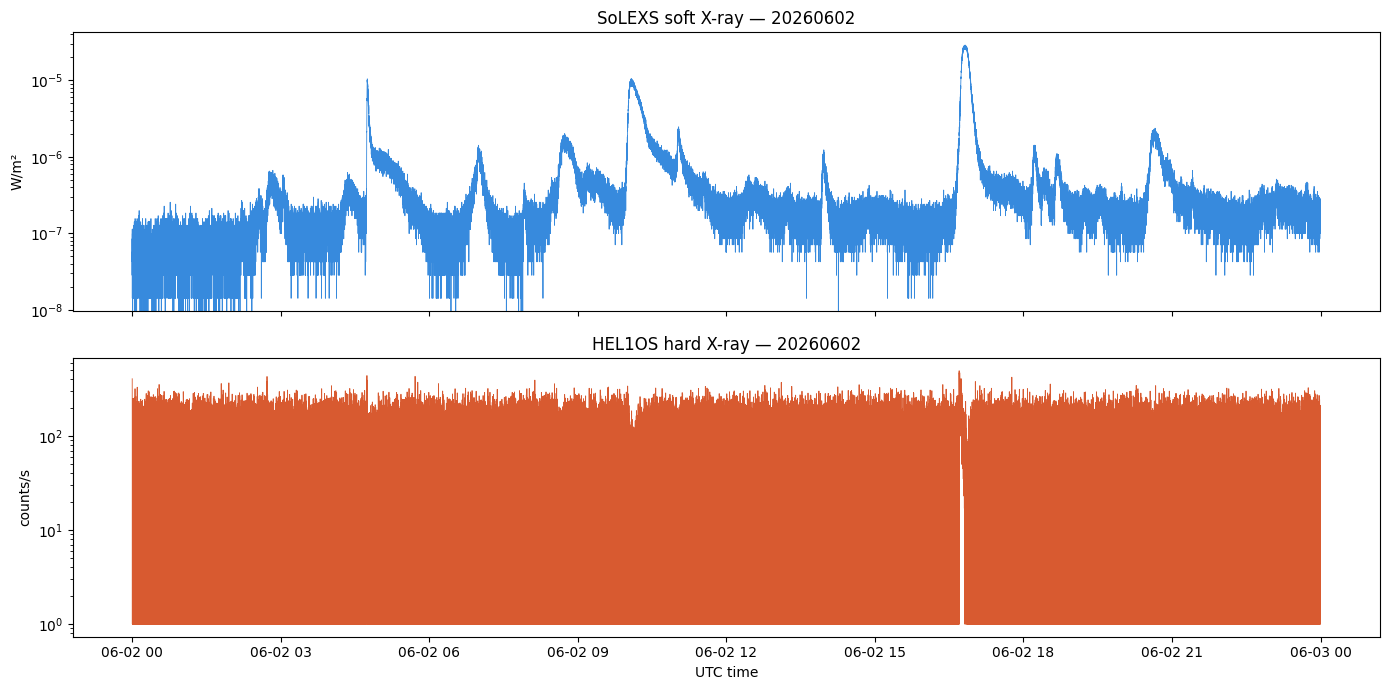

In [4]:
df = combined[DATE]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

if "SXR_FLUX" in df.columns:
    axes[0].semilogy(df.index, df["SXR_FLUX"], lw=0.6, color="#378ADD")
    axes[0].set_ylabel("W/m²")
    axes[0].set_title(f"SoLEXS soft X-ray — {DATE}")

if "HXR_COUNTS" in df.columns:
    axes[1].semilogy(df.index, df["HXR_COUNTS"].clip(lower=1), lw=0.6, color="#D85A30")
    axes[1].set_ylabel("counts/s")
    axes[1].set_title(f"HEL1OS hard X-ray — {DATE}")

axes[1].set_xlabel("UTC time")
plt.tight_layout()
plt.show()


## 5. Nowcasting — independent SXR/HXR detection, merged into a master catalogue

This calls `nowcaster.nowcast_day()` directly — same function `run_pipeline.py`
uses. See `config.py` for `SXR_THRESHOLD_SIGMA`, `HXR_BG_QUANTILE`, etc. if you
want to tune sensitivity; don't duplicate the detection logic here.


In [5]:
sxr_cat, hxr_cat, master = nowcaster.nowcast_day(df)
master


  [nowcaster] Running SXR detector ...
    → 5 SXR events detected
  [nowcaster] Running HXR detector ...
    → 142 HXR events detected
  [nowcaster] Master catalogue: 142 events (5 confirmed SXR+HXR)


,start_utc,peak_utc,end_utc,duration_s,sxr_peak_counts,snr_sxr,hxr_detected,hxr_peak_counts,snr_hxr,source,sxr_peak_flux_wm2,goes_class,goes_class_num
0,2026-06-02 00:10:50+00:00,2026-06-02 00:11:25+00:00,2026-06-02 00:11:38+00:00,48.0,NaN,NaN,True,232.0,232.0,HXR_only,NaN,?,0
1,2026-06-02 00:20:22+00:00,2026-06-02 00:20:30+00:00,2026-06-02 00:21:14+00:00,52.0,NaN,NaN,True,296.0,296.0,HXR_only,NaN,?,0
2,2026-06-02 00:26:03+00:00,2026-06-02 00:26:36+00:00,2026-06-02 00:27:13+00:00,70.0,NaN,NaN,True,261.0,261.0,HXR_only,NaN,?,0
3,2026-06-02 00:29:21+00:00,2026-06-02 00:30:48+00:00,2026-06-02 00:30:52+00:00,91.0,NaN,NaN,True,318.0,318.0,HXR_only,NaN,?,0
4,2026-06-02 00:33:13+00:00,2026-06-02 00:34:24+00:00,2026-06-02 00:35:56+00:00,163.0,NaN,NaN,True,277.0,277.0,HXR_only,NaN,?,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
137,2026-06-02 23:27:15+00:00,2026-06-02 23:27:23+00:00,2026-06-02 23:27:47+00:00,32.0,NaN,NaN,True,260.0,260.0,HXR_only,NaN,?,0
138,2026-06-02 23:31:25+00:00,2026-06-02 23:31:56+00:00,2026-06-02 23:32:26+00:00,61.0,NaN,NaN,True,261.0,261.0,HXR_only,NaN,?,0
139,2026-06-02 23:34:31+00:00,2026-06-02 23:34:41+00:00,2026-06-02 23:35:26+00:00,55.0,NaN,NaN,True,239.0,239.0,HXR_only,NaN,?,0
140,2026-06-02 23:44:47+00:00,2026-06-02 23:45:01+00:00,2026-06-02 23:45:06+00:00,19.0,NaN,NaN,True,326.0,326.0,HXR_only,NaN,?,0


Mark the confirmed (SXR+HXR) flares on the soft X-ray light curve:

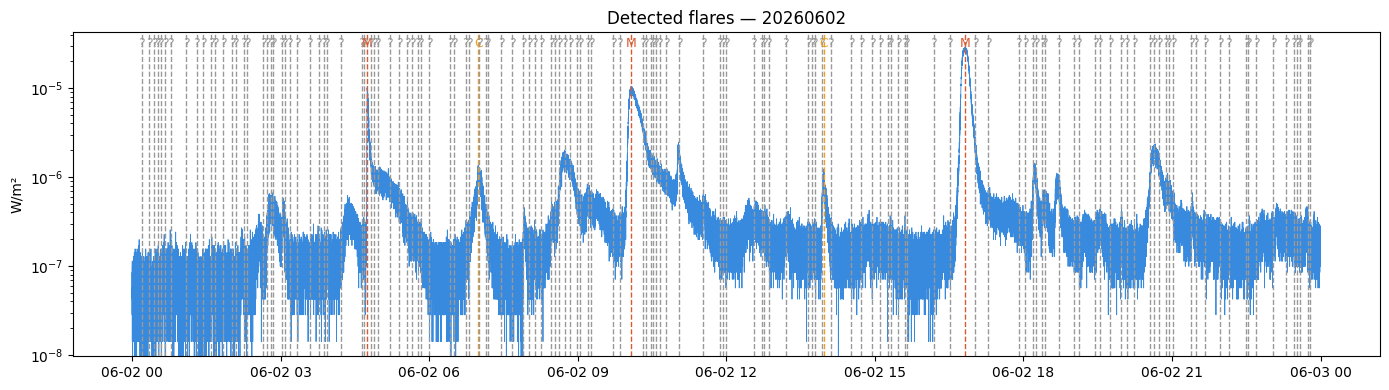

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.semilogy(df.index, df["SXR_FLUX"], lw=0.6, color="#378ADD")

class_colors = {"A": "#999999", "B": "#999999", "C": "#EF9F27", "M": "#D85A30", "X": "#A6195E"}
for _, ev in master.iterrows():
    color = class_colors.get(ev.get("goes_class", "?"), "#999999")
    ax.axvline(ev["peak_utc"], color=color, ls="--", lw=1)
    ax.annotate(ev.get("goes_class", "?"), (ev["peak_utc"], df["SXR_FLUX"].max()),
                fontsize=9, color=color, ha="center")

ax.set_ylabel("W/m²")
ax.set_title(f"Detected flares — {DATE}")
plt.tight_layout()
plt.show()


## 6. Forecasting — features, labels, training

In [7]:
# Build features + labels across ALL loaded days, not just the one plotted above —
# more days = more flare-class diversity = a better-trained model.
feat_frames, label_frames = [], []
all_master = []

for date, c in combined.items():
    _, _, day_master = nowcaster.nowcast_day(c)
    all_master.append(day_master)
    feats = forecaster.build_features(c)
    labels = forecaster.build_labels(feats, day_master)
    feat_frames.append(feats)
    label_frames.append(labels)

features_all = pd.concat(feat_frames).sort_index()
labels_all   = pd.concat(label_frames).sort_index()
master_all   = pd.concat(all_master, ignore_index=True) if all_master else pd.DataFrame()

print(f"Feature matrix: {features_all.shape}")
print(f"Flare-positive samples: {(labels_all > 0).sum()} / {len(labels_all)}")


  [nowcaster] Running SXR detector ...
    → 5 SXR events detected
  [nowcaster] Running HXR detector ...
    → 142 HXR events detected
  [nowcaster] Master catalogue: 142 events (5 confirmed SXR+HXR)
  [nowcaster] Running SXR detector ...
    → 3 SXR events detected
  [nowcaster] Running HXR detector ...
    → 151 HXR events detected
  [nowcaster] Master catalogue: 151 events (3 confirmed SXR+HXR)
  [nowcaster] Running SXR detector ...
    → 0 SXR events detected
  [nowcaster] Master catalogue: 0 events (0 confirmed SXR+HXR)
  [nowcaster] Running SXR detector ...
    → 2 SXR events detected
  [nowcaster] Running HXR detector ...
    → 138 HXR events detected
  [nowcaster] Master catalogue: 138 events (2 confirmed SXR+HXR)
  [nowcaster] Running SXR detector ...
    → 1 SXR events detected
  [nowcaster] Running HXR detector ...
    → 143 HXR events detected
  [nowcaster] Master catalogue: 143 events (1 confirmed SXR+HXR)
  [nowcaster] Running SXR detector ...
    → 1 SXR events detected

In [8]:
model, metrics = forecaster.train(features_all, labels_all)
metrics["classification_report"]


  [forecaster] Train: 8,064 samples | Test: 2,016 samples
  [forecaster] Classes present: ['Quiet', 'C', 'M', 'X'] (4/5 of the full class space)
  [forecaster] Overall accuracy: 1.000
    A/B: TPR=0.000  FPR=0.000
    C: TPR=0.000  FPR=0.000
    M: TPR=0.000  FPR=0.000
    X: TPR=0.000  FPR=0.000


{'Quiet': {'precision': 1.0,
  'recall': 1.0,
  'f1-score': 1.0,
  'support': 2016.0},
 'A/B': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0},
 'C': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0},
 'M': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0},
 'X': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0},
 'accuracy': 1.0,
 'macro avg': {'precision': 0.2,
  'recall': 0.2,
  'f1-score': 0.2,
  'support': 2016.0},
 'weighted avg': {'precision': 1.0,
  'recall': 1.0,
  'f1-score': 1.0,
  'support': 2016.0}}

## 7. Evaluation — TPR/FPR, lead time

In [9]:
lead_times = forecaster.compute_lead_times(model, features_all, master_all)
det_acc    = evaluator.detection_accuracy(master_all)
fc_summary = evaluator.forecast_metrics(lead_times)

evaluator.print_report(det_acc, fc_summary)
lead_times



  ADITYA-L1 SOLAR FLARE PIPELINE — EVALUATION REPORT

── Nowcasting Detection Accuracy ──
goes_class  n_detected
         A           0
         B           0
         C           6
         M           5
         X           1

── Forecasting Lead Time ──
  Flares with alert   : 12 / 12 (100.0%)
  Mean lead time      : 29.5 min
  Median lead time    : 29.5 min
  Range               : 29.1 – 29.9 min

  Per-class breakdown:
    C: TPR=1.00  lead_time_median=29.5 min  (N=6)
    M: TPR=1.00  lead_time_median=29.5 min  (N=5)
    X: TPR=1.00  lead_time_median=29.6 min  (N=1)



,peak_utc,goes_class,lead_time_min,alerted
0,2026-06-02 04:44:58+00:00,M,29.233333,True
1,2026-06-02 06:59:41+00:00,C,29.533333,True
2,2026-06-02 10:04:44+00:00,M,29.100000,True
3,2026-06-02 13:58:03+00:00,C,29.866667,True
4,2026-06-02 16:49:15+00:00,M,29.800000,True
5,2026-06-03 01:35:06+00:00,M,29.750000,True
6,2026-06-03 07:00:27+00:00,M,29.516667,True
7,2026-06-03 11:28:03+00:00,X,29.633333,True
8,2026-06-06 06:29:40+00:00,C,29.316667,True
9,2026-06-06 13:17:39+00:00,C,29.700000,True


## 8. Saving for the team

`run_pipeline.py` already writes all of catalogues / model / metrics to
`outputs/` automatically. If you've changed something here interactively and
want to persist it:


In [10]:
# Uncomment to overwrite the saved model with whatever you trained in this notebook
# forecaster.save_model(model, PROJECT_ROOT / config.OUTPUT_DIR / "flare_model.pkl")

print("To see this same data live, run from the project root:")
print("  streamlit run dashboard/app.py")


To see this same data live, run from the project root:
  streamlit run dashboard/app.py
